In [5]:
!pip install pytorch-tabnet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import torch

In [7]:
from google.colab import files

uploaded = files.upload()

Saving final_test_processed.csv to final_test_processed.csv
Saving final_train_processed.csv to final_train_processed.csv


In [8]:
import pandas as pd

df = pd.read_csv("final_train_processed.csv")
df = pd.read_csv("final_test_processed.csv")

print(df.shape)
df.head()

(1914, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.196483,0,0.193211,1.394672,-1.341260,0.878882,0,0,0.615301,0,0,-0.034391,0.961455,-1.195658,-0.458065,0,1,0
1,1.130834,1,-1.182269,0.011320,0.353342,0.878882,0,1,-0.244237,1,0,-0.028813,0.474536,-0.288717,-0.063557,0,0,0
2,0.637989,0,-1.182269,0.702996,1.066331,-0.772148,1,1,-0.268687,1,0,-0.026335,1.276520,1.381400,-0.679976,1,0,0
3,0.196483,1,-1.605493,-1.372033,1.240514,-0.772148,0,0,-1.094971,0,0,-0.014848,-1.065275,1.567844,0.429578,0,0,1
4,-0.265559,0,-0.441626,-1.717871,-1.341260,0.878882,1,0,0.196402,0,1,-0.034391,-1.530426,-1.195658,4.867794,0,1,0


In [9]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1914, 17)
y shape: (1914,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1531, 17)
Testing set: (383, 17)


In [11]:
X_train_np = X_train.astype(np.float32).values
X_test_np = X_test.astype(np.float32).values

y_train_np = y_train.astype(np.int64).values
y_test_np = y_test.astype(np.int64).values

print("X_train:", X_train_np.shape)
print("X_test:", X_test_np.shape)

X_train: (1531, 17)
X_test: (383, 17)


In [12]:
tabnet_model = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(
        lr=2e-3
    ),
    mask_type="entmax",
    seed=42,
    verbose=10
)

print("TabNet model created successfully!")

TabNet model created successfully!


/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [13]:
tabnet_model.fit(
    X_train_np,
    y_train_np,

    eval_set=[
        (X_train_np, y_train_np),
        (X_test_np, y_test_np)
    ],

    eval_name=[
        "train",
        "test"
    ],

    eval_metric=[
        "accuracy",
        "logloss"
    ],

    max_epochs=100,

    patience=15,

    batch_size=1024,

    virtual_batch_size=128,

    num_workers=0,

    drop_last=False
)

print("TabNet training completed!")

epoch 0  | loss: 0.92064 | train_accuracy: 0.62312 | train_logloss: 0.72509 | test_accuracy: 0.66057 | test_logloss: 0.67245 |  0:00:00s
epoch 10 | loss: 0.5296  | train_accuracy: 0.80209 | train_logloss: 0.51324 | test_accuracy: 0.80157 | test_logloss: 0.51588 |  0:00:08s
epoch 20 | loss: 0.46806 | train_accuracy: 0.80274 | train_logloss: 0.4881  | test_accuracy: 0.80418 | test_logloss: 0.5085  |  0:00:13s
epoch 30 | loss: 0.43946 | train_accuracy: 0.80797 | train_logloss: 0.46628 | test_accuracy: 0.79896 | test_logloss: 0.49897 |  0:00:21s
epoch 40 | loss: 0.42386 | train_accuracy: 0.81319 | train_logloss: 0.44435 | test_accuracy: 0.8094  | test_logloss: 0.46945 |  0:00:27s
epoch 50 | loss: 0.40064 | train_accuracy: 0.81711 | train_logloss: 0.42053 | test_accuracy: 0.79373 | test_logloss: 0.47557 |  0:00:29s
epoch 60 | loss: 0.38964 | train_accuracy: 0.82626 | train_logloss: 0.3983  | test_accuracy: 0.8094  | test_logloss: 0.45262 |  0:00:32s
epoch 70 | loss: 0.39195 | train_accuracy

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [14]:
y_pred = tabnet_model.predict(
    X_test_np
)

y_pred_proba = tabnet_model.predict_proba(
    X_test_np
)[:, 1]

In [15]:
accuracy = accuracy_score(
    y_test_np,
    y_pred
)

precision = precision_score(
    y_test_np,
    y_pred
)

recall = recall_score(
    y_test_np,
    y_pred
)

f1 = f1_score(
    y_test_np,
    y_pred
)

roc_auc = roc_auc_score(
    y_test_np,
    y_pred_proba
)

print("TabNet Results")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

TabNet Results
-------------------------
Accuracy : 0.8277
Precision: 0.6786
Recall   : 0.2500
F1 Score : 0.3654
ROC-AUC  : 0.7996


In [16]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_np,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       307
           1       0.68      0.25      0.37        76

    accuracy                           0.83       383
   macro avg       0.76      0.61      0.63       383
weighted avg       0.81      0.83      0.79       383



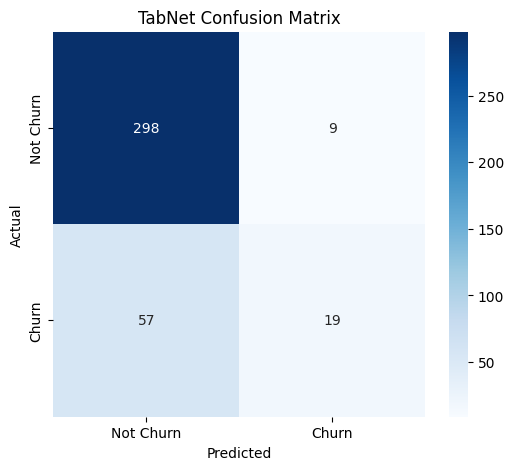

In [17]:
cm = confusion_matrix(
    y_test_np,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabNet Confusion Matrix")

plt.show()

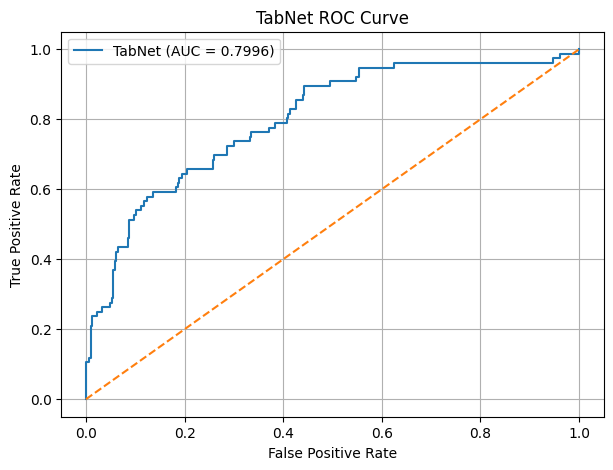

In [18]:
fpr, tpr, thresholds = roc_curve(
    y_test_np,
    y_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"TabNet (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TabNet ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tabnet_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
5        NumOfProducts    0.155436
7       IsActiveMember    0.093530
1               Gender    0.064740
10     Geography_Spain    0.062802
2                  Age    0.059602
12         TenureByAge    0.059478
6            HasCrCard    0.058657
3               Tenure    0.053981
13   BalancePerProduct    0.052088
4              Balance    0.051152
0          CreditScore    0.050540
8      EstimatedSalary    0.049901
15      ActiveWithCard    0.048680
9    Geography_Germany    0.042618
16       IsZeroBalance    0.038984
14   ProductsPerTenure    0.030943
11  BalanceSalaryRatio    0.026866


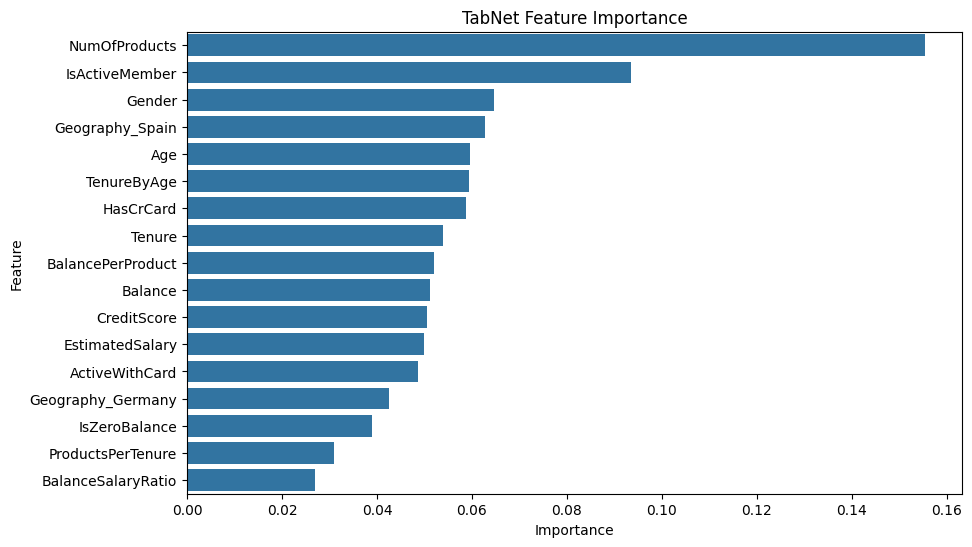

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("TabNet Feature Importance")

plt.show()

In [21]:
tabnet_model.save_model(
    "tabnet_model"
)

print("TabNet model saved successfully!")

Successfully saved model at tabnet_model.zip
TabNet model saved successfully!


In [22]:
tabnet_results = pd.DataFrame({
    "Model": ["TabNet"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

tabnet_results.to_csv(
    "tabnet_results.csv",
    index=False
)

print(tabnet_results)

    Model  Accuracy  Precision  Recall  F1_Score   ROC_AUC
0  TabNet  0.827676   0.678571    0.25  0.365385  0.799631


In [23]:
tabnet_predictions = pd.DataFrame({
    "Actual": y_test_np,
    "Predicted": y_pred,
    "Probability": y_pred_proba
})

tabnet_predictions.to_csv(
    "tabnet_predictions.csv",
    index=False
)

print("TabNet predictions saved successfully!")

TabNet predictions saved successfully!


In [24]:
tabnet_results = pd.read_csv("tabnet_predictions.csv")